In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

root_str = str(PROJECT_ROOT)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

#print("PROJECT_ROOT =", PROJECT_ROOT)
#print("cwd =", Path.cwd())

In [2]:
%load_ext autoreload
%autoreload 2

In [32]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch
import yaml
import scvi

In [33]:
control_key = "is_control"
condition_keys = "perturbation"
condition_rep_keys = "condition_embeddings"
donor_rep_keys = "donor_one_hot"
data_origin = "PBMC_donor11_hvg2000_e5test3_42_0.2_True_X_scVI_512_None" #{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}_{sample_rep_scaled}_{n_comps}
sample_rep = "X_pca"
scvi_model_load_path = f"./data/processed/model/X_scVI_ncomps512_hidden1024_layers2_PBMC_donor11_hvg2000_e5test3_42_0.2_True"
state_model_load_path = f"./data/processed/model/X_state_ArcVirtualCell.pt"
experiment = "exp_20260311_113942_PBMC_donor11_hvg2000_e5test3_42_0.2_True_X_scVI_512_None_delta20_regm1"

experiment_load_path = os.path.join("experiments",experiment)
config_load_path = os.path.join(experiment_load_path, "config.yaml")
model_load_path = os.path.join(experiment_load_path, "checkpoints", "test_11_epoch_20000.pt") 
results_save_path = os.path.join("results",experiment)
os.makedirs(results_save_path, exist_ok=True)

In [43]:
# load data
preprocess_save_path = f"./data/processed/{data_origin}"
adata_control = sc.read_h5ad(f"{preprocess_save_path}_control.h5ad")
adata_train = sc.read_h5ad(f"{preprocess_save_path}_train.h5ad")
if os.path.exists(f"{preprocess_save_path}_test.h5ad"):
    adata_test = sc.read_h5ad(f"{preprocess_save_path}_test.h5ad")
else:
    adata_test = None
print(adata_control)
print(adata_train)
print(adata_test)

AnnData object with n_obs × n_vars = 43955 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'donor_one_hot', 'is_control'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'normalized_m'
    obsm: 'X_scVI'
    layers: 'counts'
AnnData object with n_obs × n_vars = 455637 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'donor_one_hot', 'is_control'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersio

In [44]:
# load model
from src.training import FNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with open(config_load_path, 'r') as f:
    config = yaml.safe_load(f)
    print(f"load saved_config from {config_load_path}")
model = FNet(config["in_out_dim"], config["hidden_dim_v"], config["n_hiddens_v"], config["hidden_dim_g"], config["n_hiddens_g"], 
             config["condition_dim"], config["con_embedding_dim"], config["hidden_dim_con"], 
             config["time_dim"] ,config["time_embedding_dim"],config["hidden_dim_time"], 
             config["bottle_dim"], config["num_donor"], config["donor_emb_dim"],config["contain_donor"], 
             config["dropout"], config["activation"])
checkpoint = torch.load(model_load_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

load saved_config from experiments/exp_20260311_113942_PBMC_donor11_hvg2000_e5test3_42_0.2_True_X_scVI_512_None_delta20_regm1/config.yaml


FNet(
  (t_encoder): TimeEncoder()
  (activation): SiLU()
  (condition_encoder): Sequential(
    (0): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=4096, out_features=1024, bias=True)
    (2): SiLU()
    (3): Linear(in_features=1024, out_features=1024, bias=True)
    (4): SiLU()
    (5): Linear(in_features=1024, out_features=512, bias=True)
  )
  (time_encoder): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
  )
  (v_net): Velocity_GrowthNet(
    (activation): SiLU()
    (fc_in): Linear(in_features=512, out_features=1024, bias=True)
    (blocks): ModuleList(
      (0-11): 12 x FiLMResBlock(
        (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=False)
        (fc1): Linear(in_features=1024, out_features=2048, bias=True)
        (fc2): Linear(in_features=2048, out_features=1024, bias=True)
        (activation): SiLU()
        (dropout)

训练步数: 19900
最后一步 Loss: 0.287784
最后一步 vLoss: 0.274797
最后一步 gLoss: 0.012987
最后一步 test_Loss: 0.278800
最后一步 test_vLoss: 0.269133
最后一步 test_gLoss: 0.009667


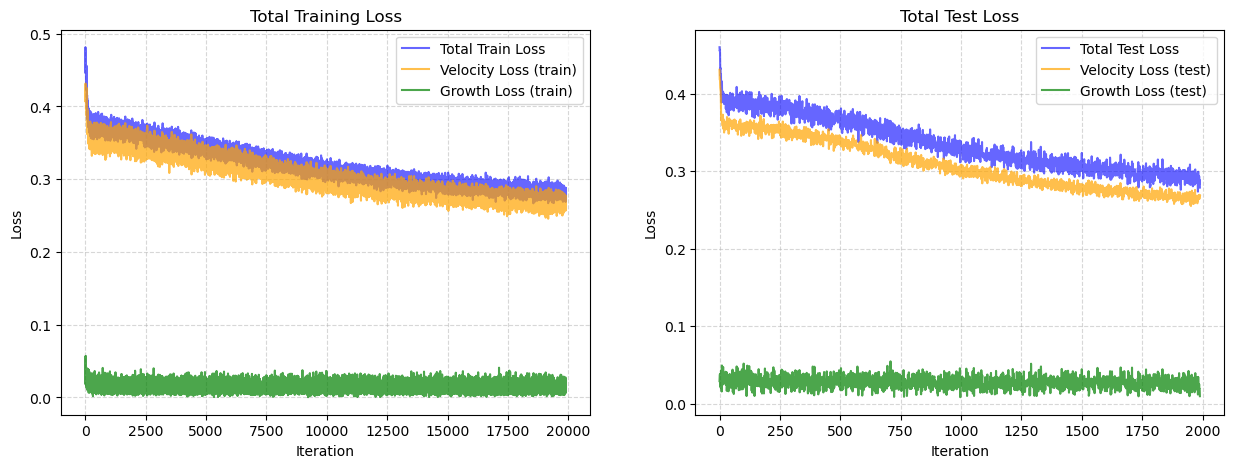

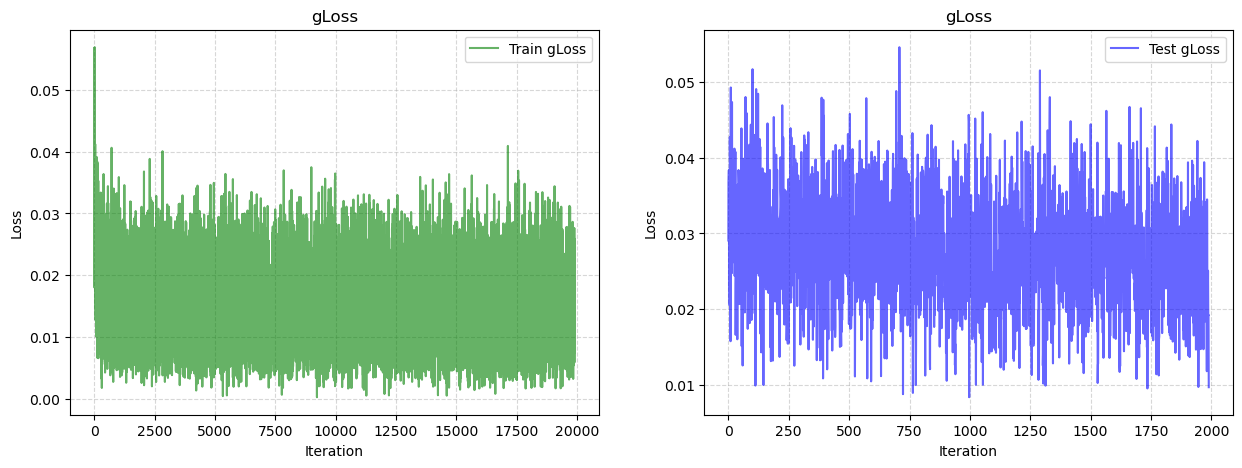

In [45]:
from src.evaluate import draw_loss
draw_loss(model_load_path,eval_interval = 10,cut = 100,save_path = results_save_path) # cut代表去掉前多少个epoch 避免前期loss过大影响观察

## inference & evalutaion

In [52]:
#condition_list = adata_test[adata_test.obs[control_key]==False].obs[condition_keys].unique()
condition_list = adata_train[adata_train.obs[control_key]==False].obs[condition_keys].unique()

In [53]:
from src.evaluate import evaluate_all

In [48]:
if sample_rep in ["X_scVI","X_scVI_linear"]:  # 用scvi去batch后的表达
    # model_ref = scvi.model.SCVI.load(f"{scvi_model_load_path}_ref", adata=adata_control)
    # model_train = scvi.model.SCVI.load(f"{scvi_model_load_path}_train", adata=adata_control)
    # model_test = scvi.model.SCVI.load(f"{scvi_model_load_path}_test", adata=adata_control)
    # from src.evaluate import get_origin_expression
    # get_origin_expression(adata_control,model_ref,target_library_size=1e4,sample_rep=sample_rep,batch_size=2048)
    # get_origin_expression(adata_train,model_train,target_library_size=1e4,sample_rep=sample_rep,batch_size=2048)
    # if adata_test is not None:
    #     get_origin_expression(adata_test,model_test,target_library_size=1e4,sample_rep=sample_rep,batch_size=2048)
    adata_control.X = adata_control.layers["counts"].copy()
    sc.pp.normalize_total(adata_control, target_sum=1e4)
    
    adata_train.X = adata_train.layers["counts"].copy()
    sc.pp.normalize_total(adata_train, target_sum=1e4)
    
    adata_test.X = adata_test.layers["counts"].copy()
    sc.pp.normalize_total(adata_test, target_sum=1e4)

if sample_rep != "X_pca_scaled": #全部放到log1p空间
    sc.pp.log1p(adata_control)
    sc.pp.log1p(adata_train)
    sc.pp.log1p(adata_test)

In [49]:
print(condition_list)

['CD27L', 'CD30L', 'EGF', 'G-CSF', 'IL-11', ..., 'LIF', 'OSM', 'PRL', 'SCF', 'TRAIL']
Length: 18
Categories (18, object): ['CD27L', 'CD30L', 'EGF', 'G-CSF', ..., 'OSM', 'PRL', 'SCF', 'TRAIL']


In [54]:
target_list = condition_list
final_df, artifacts = evaluate_all(
    model=model,
    adata_control=adata_control,
    adata_test=adata_train,
    target_genes=target_list,
    condition_keys=condition_keys,
    control_key=control_key,
    condition_rep_keys=condition_rep_keys,
    donor_rep_keys=donor_rep_keys,
    sample_rep=sample_rep,
    device=device,
    n_particles = 20000,
    random_seed = 42,
    n_steps = 50,
    Edistance_sample_num = 20000,
    dist_max_cells = 20000,
    dist_n_bins = 200,
    dist_top_n_degs = 50,
    results_save_path=results_save_path,
    scvi_model_load_path=scvi_model_load_path,
    state_model_load_path=state_model_load_path,
    save_each = False,
    save_final = True,
    final_filename = f"final_metrics1_finetune_test_test.csv",
    detailed = True #是否只看mean
)

100%|██████████| 72/72 [10:55<00:00,  9.10s/it]

INFO     File                                                                                                      
         ./data/processed/model/X_scVI_ncomps512_hidden1024_layers2_PBMC_donor11_hvg2000_e5test3_42_0.2_True_ref/mo
         del.pt already downloaded                                                                                 
INFO     File                                                                                                      
         ./data/processed/model/X_scVI_ncomps512_hidden1024_layers2_PBMC_donor11_hvg2000_e5test3_42_0.2_True_train/
         model.pt already downloaded                                                                               


INFO     File                                                                                                      
         ./data/processed/model/X_scVI_ncomps512_hidden1024_layers2_PBMC_donor11_hvg2000_e5test3_42_0.2_True_test/m
         odel.pt already downloaded                                                                                


  0%|          | 0/72 [00:00<?, ?it/s]/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
  1%|▏         | 1/72 [00:00<00:08,  8.02it/s]/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
  3%|▎         | 2/72 [00:00<00:08,  8.11it/s]/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
  4%|▍         | 3/72 [00:00<00:08,  8.09it/s]/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprec

Start evaluating 72 perturbations (Pseudo-bulk)
Start evaluating 72 perturbations (Pseudo-bulk)
Start evaluating 72 perturbations (Distribution metrics)


/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  uti

In [55]:
print(final_df)

   perturbation  latent_mse  latent_cosine  latent_delta_cosine  mse_gene  \
0        4-1BBL    0.002488       0.651419             0.737225  0.115321   
1          ADSF    0.002519       0.236252             0.306881  0.109338   
2         APRIL    0.002775       0.286171             0.389779  0.099728   
3          BAFF    0.002317       0.704037             0.807100  0.112397   
4           C5a    0.002578       0.821294             0.851783  0.107340   
..          ...         ...            ...                  ...       ...   
68          TPO    0.002085       0.687597             0.727191  0.118634   
69         TSLP    0.002574       0.673381             0.716491  0.121659   
70        TWEAK    0.002642       0.386592             0.284837  0.110440   
71         VEGF    0.002647       0.427689             0.615905  0.107666   
72         mean    0.002716       0.577277             0.607873  0.116584   

    mse_true  mae_gene   r2_gene   r2_true  r2_gene_deg50  ...  \
0   0.003

In [35]:
indices = artifacts["indices"]
results_embedding = artifacts["results_embedding"]
results_genes = artifacts["results_genes"]

In [16]:
!pwd

/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM


In [21]:
sc.tl.pca(adata_control, svd_solver='arpack')
sc.pp.neighbors(adata_control, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_control)

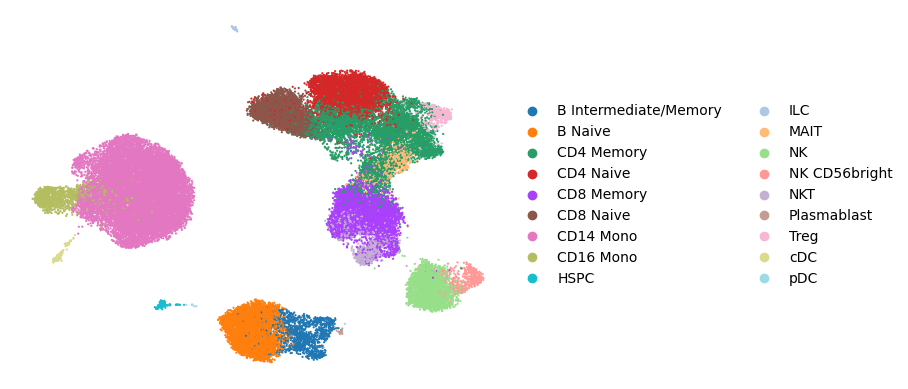

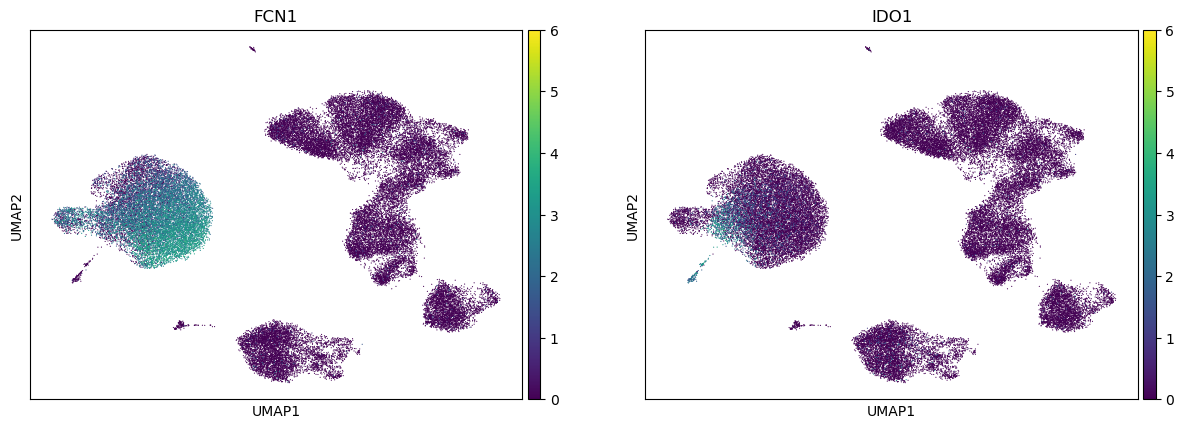

In [34]:
sc.pl.umap(
    adata_control, 
    color='cell_type',      # 按细胞类型着色
    frameon=False,          # 【关键】去掉周围的黑框和坐标轴
    title='',               # 去掉标题（方便后期AI排版）
    legend_fontsize=10,     # 标签字体大小
    size=10,                # 调整点的大小
    save='celltype.pdf'    # 保存为矢量图
)
sc.pl.umap(
    adata_control, 
    vmin=0,
    vmax=6,
    color=[f'FCN1', f'IDO1'], 
)

In [23]:
adata_true = adata_test[adata_test.obs["cytokine"]=="IL-15"].copy()
adata_pred = results_genes["IL-15"]

In [24]:
sc.tl.ingest(adata_true, adata_control, embedding_method='umap')
sc.tl.ingest(adata_pred, adata_control, embedding_method='umap')

/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [25]:
adata_control.obs['dataset'] = 'Control'
adata_true.obs['dataset'] = 'True'
adata_pred.obs['dataset'] = 'Pred'

/tmp/ipykernel_1821481/3828266796.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = adata_control.concatenate(adata_true, batch_key='dataset',batch_categories=["Control", "True"])


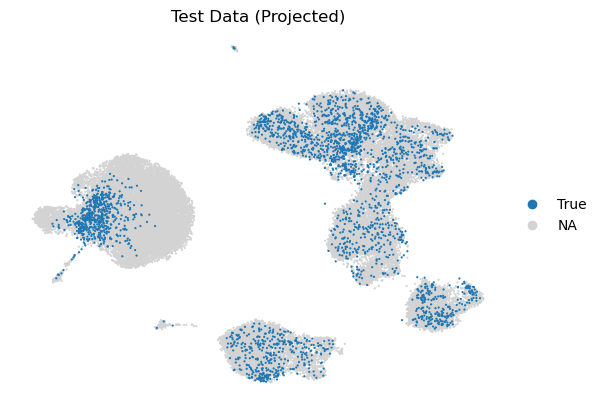

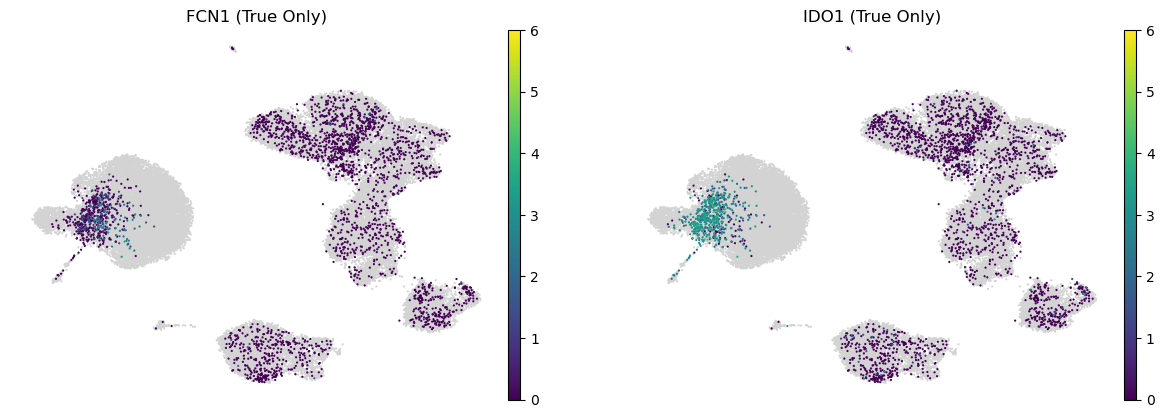

In [35]:
adata_all = adata_control.concatenate(adata_true, batch_key='dataset',batch_categories=["Control", "True"])

adata_all.obs['plot_color'] = adata_all.obs['dataset'].astype(str)
color_map = {'Control': 'black', 'True': '#1f77b4'} # 也可以用 hex 颜色码

# sc.pl.umap(
#     adata_all, 
#     color='plot_color', 
#     groups=['Control'], # 只高亮 Control
#     palette=color_map,
#     frameon=False,
#     title='Control',
#     size=10 # 根据细胞数调整点大小
# )

sc.pl.umap(
    adata_all, 
    color='plot_color', 
    groups=['True'],    # 只高亮 Test
    palette=color_map,
    frameon=False,
    title='Test Data (Projected)',
    size=10
)
import numpy as np

# 1. 复制一个用于绘图的对象，以免修改原数据
adata_plot = adata_all.copy()

# 2. 将 'Control' 组的这两个基因的表达量设为 NaN (空值)
# 这样 Scanpy 就会把它们识别为缺失值，并涂上 na_color
mask_control = adata_plot.obs['dataset'] == 'Control'

# 注意：如果 .X 是稀疏矩阵，操作稍微麻烦点；如果是 dense 矩阵或已放到 .obs 里可以直接操作
# 这里演示最通用的方法：先把基因值存入 obs，再手动修改
for gene in ['FCN1', 'IDO1']:
    # 获取表达量 (处理稀疏矩阵的情况)
    if hasattr(adata_plot.X, "toarray"):
        values = adata_plot[:, gene].X.toarray().flatten()
    else:
        values = adata_plot[:, gene].X.flatten()
    
    # 存入 obs
    adata_plot.obs[f'plot_{gene}'] = values
    
    # 将 Control 组的值设为 NaN
    adata_plot.obs.loc[mask_control, f'plot_{gene}'] = np.nan

# 3. 绘图
sc.pl.umap(
    adata_plot, 
    color=[f'plot_FCN1', f'plot_IDO1'], 
    na_color='lightgrey', # 这里设置背景色（Control的颜色）
    na_in_legend=False,   # 图例中不显示 NaN
    cmap='viridis',       # Pred 组的颜色映射
    frameon=False,
    vmin=0,
    vmax=6,
    size=10,
    title=['FCN1 (True Only)', 'IDO1 (True Only)']
)


/tmp/ipykernel_1821481/2352833824.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = adata_control.concatenate(adata_pred, batch_key='dataset',batch_categories=["Control", "Pred"])


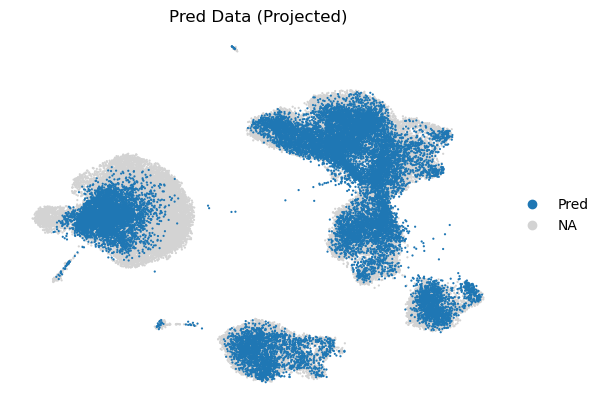

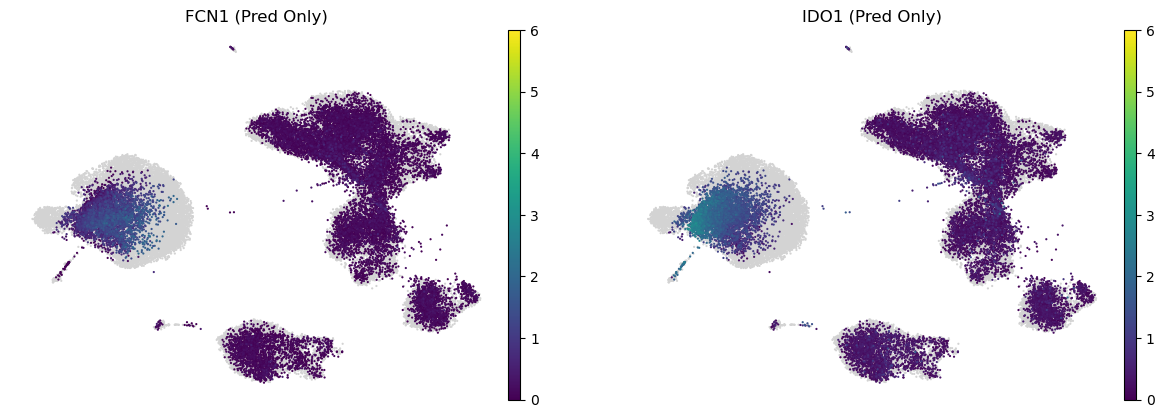

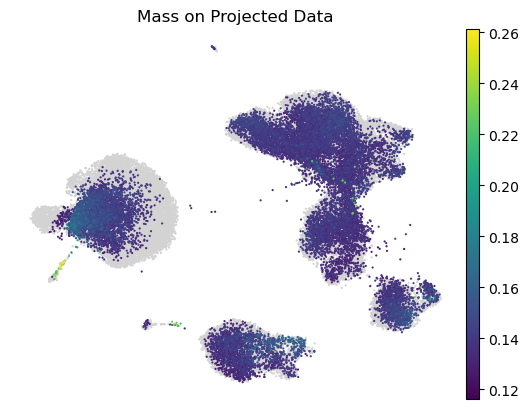

In [42]:
adata_all = adata_control.concatenate(adata_pred, batch_key='dataset',batch_categories=["Control", "Pred"])

adata_all.obs['plot_color'] = adata_all.obs['dataset'].astype(str)
color_map = {'Control': 'black', 'Pred': '#1f77b4'} # 也可以用 hex 颜色码

sc.pl.umap(
    adata_all, 
    color='plot_color', 
    groups=['Pred'],    # 只高亮 Test
    palette=color_map,
    frameon=False,
    title='Pred Data (Projected)',
    size=10
)


import numpy as np

# 1. 复制一个用于绘图的对象，以免修改原数据
adata_plot = adata_all.copy()

# 2. 将 'Control' 组的这两个基因的表达量设为 NaN (空值)
# 这样 Scanpy 就会把它们识别为缺失值，并涂上 na_color
mask_control = adata_plot.obs['dataset'] == 'Control'

# 注意：如果 .X 是稀疏矩阵，操作稍微麻烦点；如果是 dense 矩阵或已放到 .obs 里可以直接操作
# 这里演示最通用的方法：先把基因值存入 obs，再手动修改
for gene in ['FCN1', 'IDO1']:
    # 获取表达量 (处理稀疏矩阵的情况)
    if hasattr(adata_plot.X, "toarray"):
        values = adata_plot[:, gene].X.toarray().flatten()
    else:
        values = adata_plot[:, gene].X.flatten()
    
    # 存入 obs
    adata_plot.obs[f'plot_{gene}'] = values
    
    # 将 Control 组的值设为 NaN
    adata_plot.obs.loc[mask_control, f'plot_{gene}'] = np.nan

# 3. 绘图
sc.pl.umap(
    adata_plot, 
    color=[f'plot_FCN1', f'plot_IDO1'], 
    na_color='lightgrey', # 这里设置背景色（Control的颜色）
    na_in_legend=False,   # 图例中不显示 NaN
    cmap='viridis',       # Pred 组的颜色映射
    frameon=False,
    vmin=0,
    vmax=6,
    size=10,
    title=['FCN1 (Pred Only)', 'IDO1 (Pred Only)']
)
import numpy as np

# 1. 复制一份用于绘图，避免污染原数据
adata_plot = adata_all.copy()

# 2. 初始化一个新的列用于绘图，先全部设为 NaN (灰色)
adata_plot.obs['plot_mass'] = np.nan

# 3. 找到 Pred 组的位置
mask_pred = adata_plot.obs['dataset'] == 'Pred'

# 4. 将 mass 的值填入 Pred 组对应的位置
# .values 确保赋值时忽略索引名称差异（concat 可能会改索引名）
adata_plot.obs.loc[mask_pred, 'plot_mass'] = adata_pred.obs['mass'].values

# 5. 绘图
sc.pl.umap(
    adata_plot, 
    color='plot_mass', 
    na_color='lightgrey', # Control 组（NaN）显示的颜色
    na_in_legend=False,   # 图例中不显示灰色
    cmap='viridis',       # mass 的色阶
    frameon=False,
    size=10,
    title='Mass on Projected Data'
)

In [38]:
adata_pred

AnnData object with n_obs × n_vars = 20000 × 5412
    obs: 'condition', 'mass', 'dataset'
    uns: 'reconstruction_params'
    obsm: 'rep', 'X_umap'

=== Mass Statistics for CDCA2 prediction ===
Mean Mass: 0.0433
Max  Mass: 0.0472
Min  Mass: 0.0411
Std  Mass: 0.0009


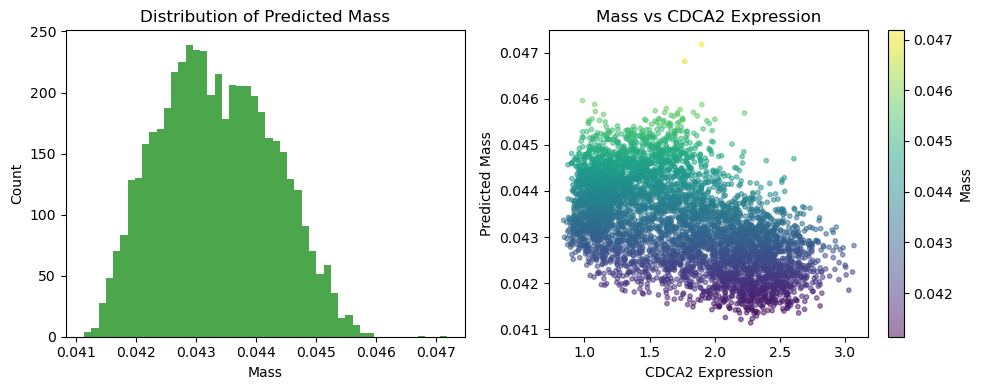

=== Mass Statistics for DHX36 prediction ===
Mean Mass: 0.0351
Max  Mass: 0.0530
Min  Mass: 0.0284
Std  Mass: 0.0031


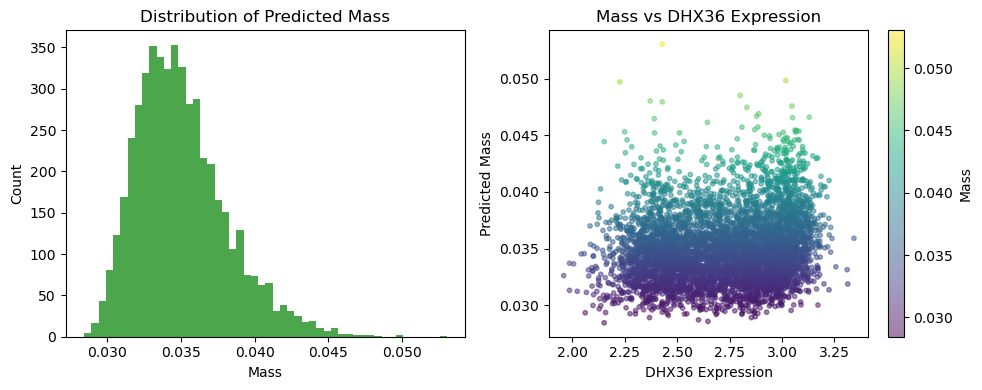

=== Mass Statistics for TMSB10 prediction ===
Mean Mass: 0.0230
Max  Mass: 0.0280
Min  Mass: 0.0209
Std  Mass: 0.0009


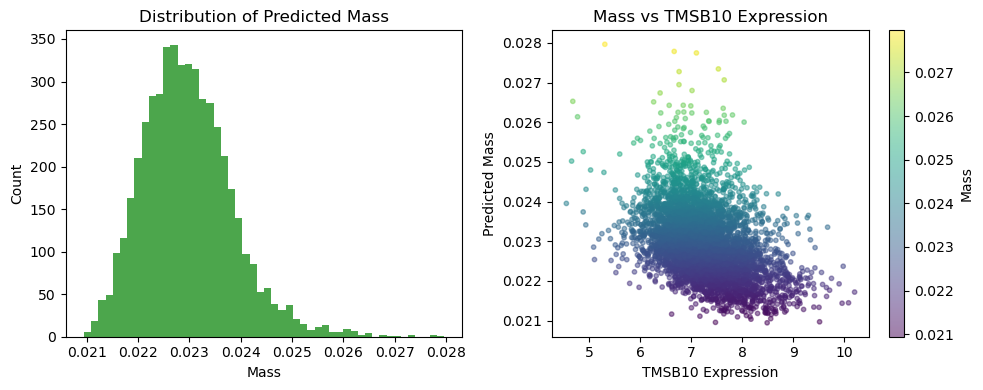

=== Mass Statistics for KAT2A prediction ===
Mean Mass: 0.0525
Max  Mass: 0.0689
Min  Mass: 0.0452
Std  Mass: 0.0032


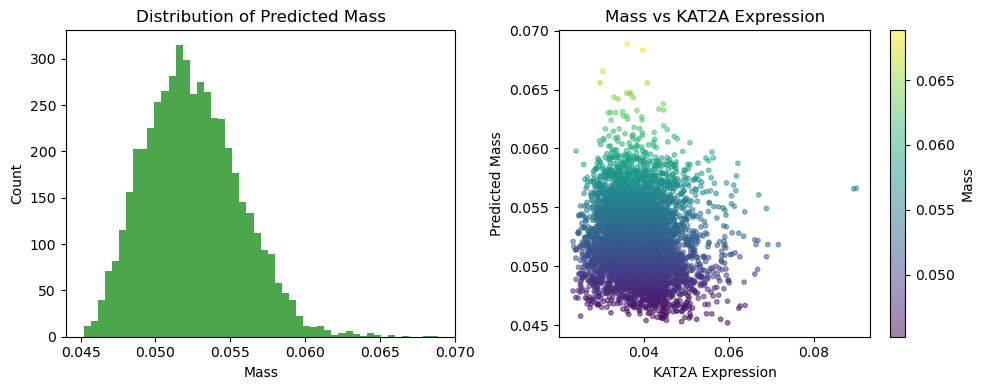

=== Mass Statistics for PHF14 prediction ===
Mean Mass: 0.0236
Max  Mass: 0.0274
Min  Mass: 0.0225
Std  Mass: 0.0005


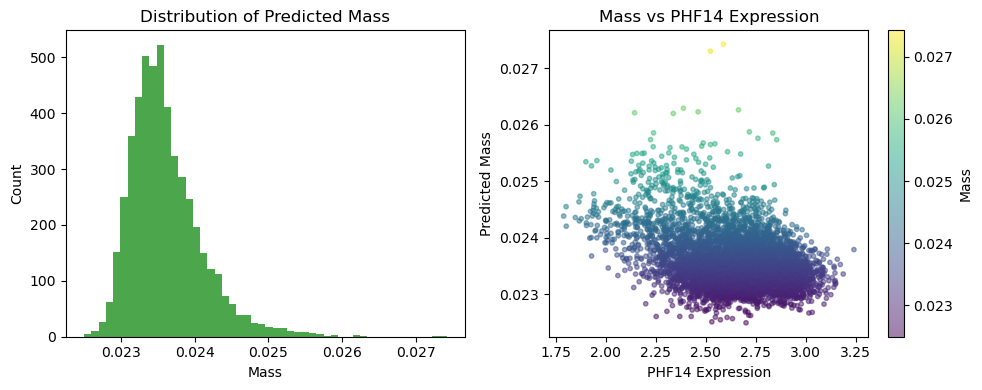

=== Mass Statistics for KLF10 prediction ===
Mean Mass: 0.0484
Max  Mass: 0.0560
Min  Mass: 0.0455
Std  Mass: 0.0017


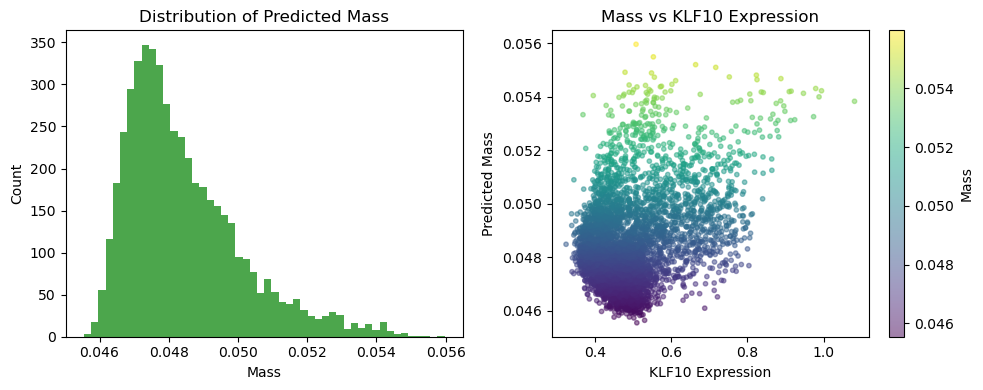

=== Mass Statistics for KDM1A prediction ===
Mean Mass: 0.0095
Max  Mass: 0.0193
Min  Mass: 0.0053
Std  Mass: 0.0021


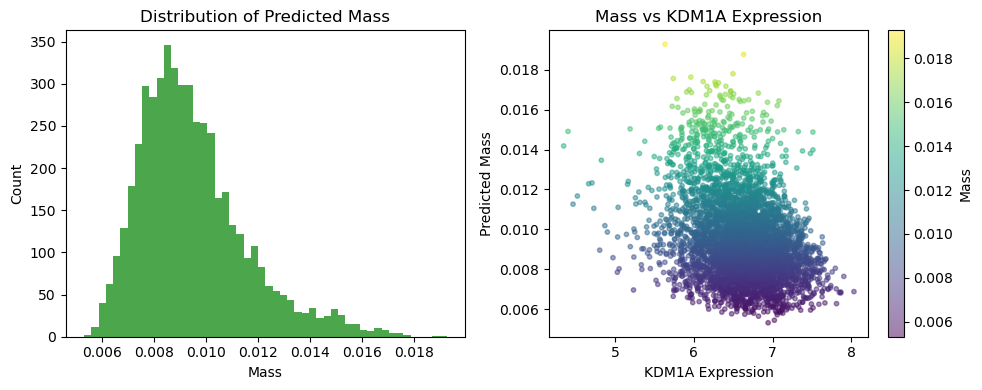

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def diagnose_mass_prediction(pred_adata, gene_name='CDCA2'):
    mass = pred_adata.obs['mass'].values
    expr = pred_adata[:, gene_name].X.flatten() # 或者是 .layers['counts'] 等
    
    # 1. 打印统计数据
    print(f"=== Mass Statistics for {gene_name} prediction ===")
    print(f"Mean Mass: {np.mean(mass):.4f}")
    print(f"Max  Mass: {np.max(mass):.4f}")
    print(f"Min  Mass: {np.min(mass):.4f}")
    print(f"Std  Mass: {np.std(mass):.4f}")
    
    # 2. 绘图：Mass vs Target Gene Expression
    plt.figure(figsize=(10, 4))
    
    # 子图1: Mass 的直方图
    plt.subplot(1, 2, 1)
    plt.hist(mass, bins=50, color='green', alpha=0.7)
    plt.title("Distribution of Predicted Mass")
    plt.xlabel("Mass")
    plt.ylabel("Count")
    
    # 子图2: Mass vs Expression
    plt.subplot(1, 2, 2)
    plt.scatter(expr, mass, alpha=0.5, s=10, c=mass, cmap='viridis')
    plt.title(f"Mass vs {gene_name} Expression")
    plt.xlabel(f"{gene_name} Expression")
    plt.ylabel("Predicted Mass")
    plt.colorbar(label='Mass')
    
    plt.tight_layout()
    plt.show()

# 运行诊断
for gene in target_genes:
    diagnose_mass_prediction(results_genes[gene], gene)